In [1]:
!!cd /content/
!!rm -rf 400 Termproject aenet sample_data

[]

In [2]:
try:
  import aenet
  print("successfully imported aenet")
except ImportError:
  !! git clone https://github.com/atomisticnet/aenet.git
  !! cd aenet/lib && make
  !! cd aenet/src && make -f makefiles/Makefile.gfortran_serial
  !! cd aenet/src && make -f makefiles/Makefile.gfortran_serial lib
  !! cd aenet/python3 && python3 setup.py build_ext --inplace
  !! cd aenet/python3 && pip install -e . --user
  print("completed installation of aenet")

completed installation of aenet


In [3]:
import os
if not os.path.exists('Termproject'):
  !! git clone https://github.com/yachamashok/Termproject.git
else:
  print("Tutorial files are already installed.")
!!cd Termproject/
!!unzip Termproject/400.zip

['Archive:  Termproject/400.zip',
 '   creating: 400/',
 '   creating: 400/01-generate/',
 '  inflating: 400/01-generate/gen.in  ',
 '  inflating: 400/01-generate/Ni.fingerprint.stp  ',
 '  inflating: 400/timestep_1376200000.xsf  ',
 '  inflating: 400/timestep_1325000000.xsf  ',
 '  inflating: 400/timestep_1325100000.xsf  ',
 '  inflating: 400/timestep_1325200000.xsf  ',
 '  inflating: 400/timestep_1325300000.xsf  ',
 '  inflating: 400/timestep_1325400000.xsf  ',
 '  inflating: 400/timestep_1325500000.xsf  ',
 '  inflating: 400/timestep_1325600000.xsf  ',
 '  inflating: 400/timestep_1325700000.xsf  ',
 '  inflating: 400/timestep_1325800000.xsf  ',
 '  inflating: 400/timestep_1325900000.xsf  ',
 '  inflating: 400/timestep_1326000000.xsf  ',
 '  inflating: 400/timestep_1326100000.xsf  ',
 '  inflating: 400/timestep_1326200000.xsf  ',
 '  inflating: 400/timestep_1326300000.xsf  ',
 '  inflating: 400/timestep_1326400000.xsf  ',
 '  inflating: 400/timestep_1326500000.xsf  ',
 '  inflating: 

In [4]:
import numpy as np
import pandas as pd
import re
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import Image
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, zoomed_inset_axes
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 15})
plt.close("all")

In [5]:
try:
  import ase
  print("successfully imported ase")
except ImportError:
  !! pip install ase --user --upgrade
  print("completed installing ASE")

successfully imported ase


In [6]:
try:
  import aenet
  import ase
  print("Both aenet and ase could be imported. You are all set for the tutorial.")
except ImportError:
  print("The notebook needs to be restarted. Run this cell again once the restart is done.")
  import os
  os.kill(os.getpid(), 9)
import ase
import ase.spacegroup
import ase.visualize
atoms = ase.io.read("/content/400/timestep_1325000000.xsf")
ase.visualize.view(atoms, viewer='x3d')

Both aenet and ase could be imported. You are all set for the tutorial.


In [7]:
%cd /content/400/01-generate
%ls
! head -n 15 gen.in

/content/400/01-generate
gen.in  Ni.fingerprint.stp
OUTPUT Ni.train

TYPES
1
Ni   -207.27  ! eV

SETUPS
Ni   Ni.fingerprint.stp

FILES
751
../timestep_1325000000.xsf
../timestep_1325100000.xsf
../timestep_1325200000.xsf
../timestep_1325300000.xsf


In [8]:
!cat Ni.fingerprint.stp

DESCR
  Structural fingerprint setup for Ni in bulk Ni
  Ref.: N. Artrith and A. Urban, Comp. Mater. Sci. (2016)
END DESCR

ATOM Ni

ENV  1
Ni

RMIN 0.75d0

SYMMFUNC type=Behler2011
70
G=2 type2=Ni   eta=0.003214  Rs=0.0000  Rc=6.5000
G=2 type2=Ni  eta=0.003214  Rs=0.0000  Rc=6.5000
G=2 type2=Ni   eta=0.035711  Rs=0.0000  Rc=6.5000
G=2 type2=Ni  eta=0.035711  Rs=0.0000  Rc=6.5000
G=2 type2=Ni   eta=0.071421  Rs=0.0000  Rc=6.5000
G=2 type2=Ni  eta=0.071421  Rs=0.0000  Rc=6.5000
G=2 type2=Ni   eta=0.124987  Rs=0.0000  Rc=6.5000
G=2 type2=Ni  eta=0.124987  Rs=0.0000  Rc=6.5000
G=2 type2=Ni   eta=0.214264  Rs=0.0000  Rc=6.5000
G=2 type2=Ni  eta=0.214264  Rs=0.0000  Rc=6.5000
G=2 type2=Ni   eta=0.357106  Rs=0.0000  Rc=6.5000
G=2 type2=Ni  eta=0.357106  Rs=0.0000  Rc=6.5000
G=2 type2=Ni   eta=0.714213  Rs=0.0000  Rc=6.5000
G=2 type2=Ni  eta=0.714213  Rs=0.0000  Rc=6.5000
G=2 type2=Ni   eta=1.428426  Rs=0.0000  Rc=6.5000
G=2 type2=Ni  eta=1.428426  Rs=0.0000  Rc=6.5000
G=4 type2=Ni  type3=Ni 

In [9]:
! rm -r Ni.train
! /content/aenet/bin/generate.x-2.0.4-gfortran_serial gen.in > generate.out
print("Reference data set generation completed")
%ls            

rm: cannot remove 'Ni.train': No such file or directory
 >>> T F
 Error: incomplete output data in : ../timestep_1325000000.xsf
Reference data set generation completed
generate.out  gen.in  Ni.fingerprint.stp  Ni.train


In [10]:
%ls
!cat generate.out

generate.out  gen.in  Ni.fingerprint.stp  Ni.train
                  generate.x - training set generation                 

 Copyright (C) 2015-2018 Nongnuch Artrith and Alexander Urban

 This program is distributed in the hope that it will be useful, but
 WITHOUT ANY WARRANTY; without even the implied warranty of
 MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
 Mozilla Public License, v. 2.0, for more details.

 ----------------------------------------------------------------------
                   Generation of training set started                  
 ----------------------------------------------------------------------

 Number of atom types  : 1
 types                 :    Ni 
 Number of structures  : 751

 ----------------------------------------------------------------------
                  Structural fingerprint basis set-up                  
 ----------------------------------------------------------------------

 Structural fingerprint (SF) set-up for Ni

  

In [11]:
%cd /content/400/02-train
%ls

/content/400/02-train
train.in


In [12]:
%cat train.in

TRAININGSET Ni.train
TESTPERCENT 20
ITERATIONS  50

MAXENERGY 0.0

TIMING

SAVE_ENERGIES

METHOD
lm batchsize=8000 learnrate=0.1d0 iter=3 conv=0.001 adjust=5.0

! METHOD 1 Steepest Descent
! online_sd gamma=5.0d-7 alpha=0.25d0
! online_sd gamma=1.0d-8 alpha=0.25d0
!
! METHOD 2 Limited-Memory BFGS
! bfgs
!
! METHOD 3 Levenberg-Marquardt
! lm batchsize=8000 learnrate=0.1d0 iter=3 conv=0.001 adjust=5.0

NETWORKS
! atom   network         hidden
! types  file-name       layers  nodes:activation
  Ni       Ni.10tw-10tw.ann   2    10:tanh 10:tanh


In [13]:
! rm -r Ni.train
! cp ../01-generate/Ni.train .
%ls

rm: cannot remove 'Ni.train': No such file or directory
Ni.train  train.in


In [14]:
! rm -r TRAIN.0 TEST.0 Ni.* 
! /content/aenet/bin/train.x-2.0.4-gfortran_serial train.in | tee train.out
%ls

rm: cannot remove 'TRAIN.0': No such file or directory
rm: cannot remove 'TEST.0': No such file or directory
                       Training process started.                       
                                                                       
                          2023-05-20  16:33:47                         
                                                                       

 Copyright (C) 2015-2018 Nongnuch Artrith and Alexander Urban

 This program is distributed in the hope that it will be useful, but
 WITHOUT ANY WARRANTY; without even the implied warranty of
 MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
 Mozilla Public License, v. 2.0, for more details.

 Error: file not found: Ni.train
train.in  train.out


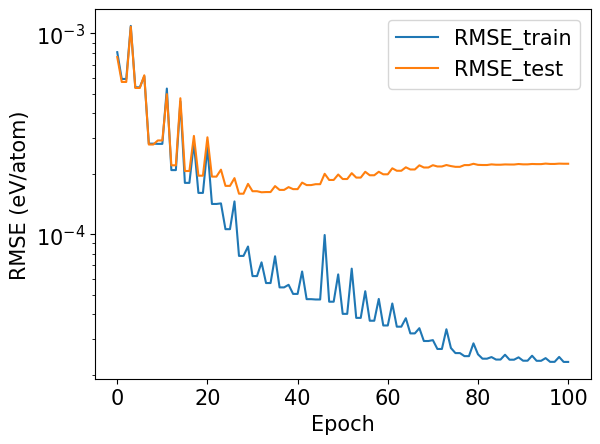

In [ ]:
errors = []
with open("/content/400/02-train/train.out") as fp:
  for line in fp:
    if re.match("^ *[0-9].*<$", line):
      errors.append([float(a) for a in line.split()[1:-1]])
errors = np.array(errors)
errors = pd.DataFrame(
    data=errors, 
    columns=['MAE_train', 'RMSE_train', 'MAE_test', 'RMSE_test'])
ax = errors[['RMSE_train', 'RMSE_test']].plot(logy=True)
ax.set_xlabel("Epoch"); ax.set_ylabel("RMSE (eV/atom)")
plt.show()

<function r2_score at 0x7f5dc8a67370>


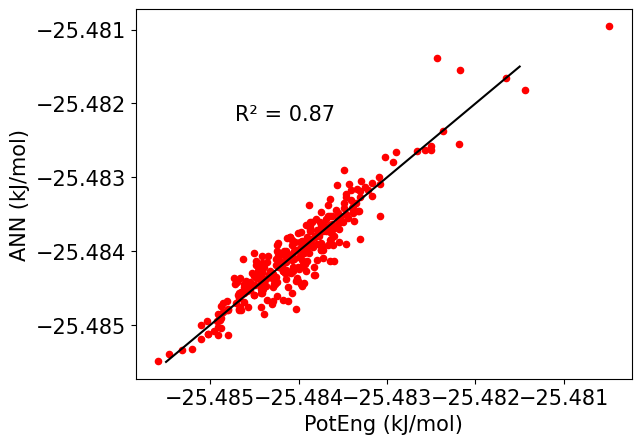

In [ ]:
test = "/content/400/02-train/energies.test.0"
test_errors = np.loadtxt(test, skiprows=1, usecols=(3,4))
limits = np.linspace(-25.4815, -25.4855)
plt.plot(limits, limits, color="black")
plt.ticklabel_format(useOffset=False)
plt.scatter(test_errors[:,0], test_errors[:,1], color="red", s=20, label="validation")
plt.xlabel('PotEng (kJ/mol)')
plt.ylabel('ANN (kJ/mol)')
r2 = r2_score(test_errors[:,0], test_errors[:,1])
plt.annotate(f"R² = {r2:.2f}", xy=(0.2,0.7), xycoords='axes fraction')
print(r2_score)
plt.show()

In [ ]:
%cd /content/400/03-predict/
!cp ../02-train/Ni.10tw-10tw.ann .
! /content/aenet/bin/predict.x-2.0.4-gfortran_serial predict.in | tee predict.out
%ls

Streaming output truncated to the last 5000 lines.
          type       = Behler2011 4
          covariance =    2.4329039165746655E-029
          average    =    2.8734735003314306E-016
          min, max   =    0.0000000000000000        2.0981569562004425E-013
          This means at least one fingerprint function for O is always equal to zero!
          Maybe an atomic species is not present in the reference set?
          type       = Behler2011 4
          covariance =    2.4329039165746655E-029
          average    =    2.8734735003314306E-016
          min, max   =    0.0000000000000000        2.0981569562004425E-013
          This means at least one fingerprint function for O is always equal to zero!
          Maybe an atomic species is not present in the reference set?
          type       = Behler2011 4
          covariance =    2.4329039165746655E-029
          average    =    2.8734735003314306E-016
          min, max   =    0.0000000000000000        2.0981569562004425E-013